# CTF LLM Performance Analysis
**Dataset:** `combined_question_list_with_score_difficulty_typed.json`  
**Models:** gpt-5-mini, o4-mini, gpt-4o  
**Challenge Types:** crypto, pwn, misc, reverse, web, forensics  
**Question Formats:** Multiple Choice (MC) + Open-Ended (Short Answer)


In [2]:
import json, re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

# ── Load & Parse ──────────────────────────────────────────────────────────────
with open('combined_question_list_with_score_difficulty_typed.json', 'r') as f:
    data = json.load(f)

df = pd.DataFrame(data)
LLMs = ['gpt-5-mini', 'o4-mini', 'gpt-4o']
TYPES = ['crypto', 'pwn', 'misc', 'reverse', 'web', 'forensics']
COLORS = {'gpt-5-mini': '#4A90E2', 'o4-mini': '#E67E22', 'gpt-4o': '#2ECC71'}
TYPE_COLORS = ['#4A90E2','#E67E22','#2ECC71','#9B59B6','#E74C3C','#1ABC9C']

# MC correctness (top-level LLM column)
for llm in LLMs:
    df[f'mc_{llm}'] = df[llm].apply(lambda x: 1 if x == 'correct' else 0)

# Open-ended correctness from short_answer_results
def get_oe(row, llm):
    for r in row.get('short_answer_results', []):
        if r.get('llm') == llm:
            return 1 if r.get('judge') == 'correct' else 0
    return 0

for llm in LLMs:
    df[f'oe_{llm}'] = df.apply(lambda row: get_oe(row, llm), axis=1)

# Difficulty bins
def diff_bin(d):
    if d < 0: return 'N/A'
    if d < 0.3: return 'Easy'
    if d < 0.6: return 'Medium'
    if d < 0.8: return 'Hard'
    return 'Very Hard'

df['diff_bin'] = df['difficulty'].apply(diff_bin)

print(f"Total questions: {len(df)}")
print(f"Types: {df['type'].value_counts().to_dict()}")
print(f"Difficulty bins: {df['diff_bin'].value_counts().to_dict()}")


Total questions: 398
Types: {'crypto': 116, 'pwn': 112, 'misc': 57, 'reverse': 56, 'web': 44, 'forensics': 13}
Difficulty bins: {'Very Hard': 110, 'Easy': 90, 'N/A': 86, 'Medium': 77, 'Hard': 35}


## 1. Overall Correctness Rate: Multiple Choice vs Open-Ended

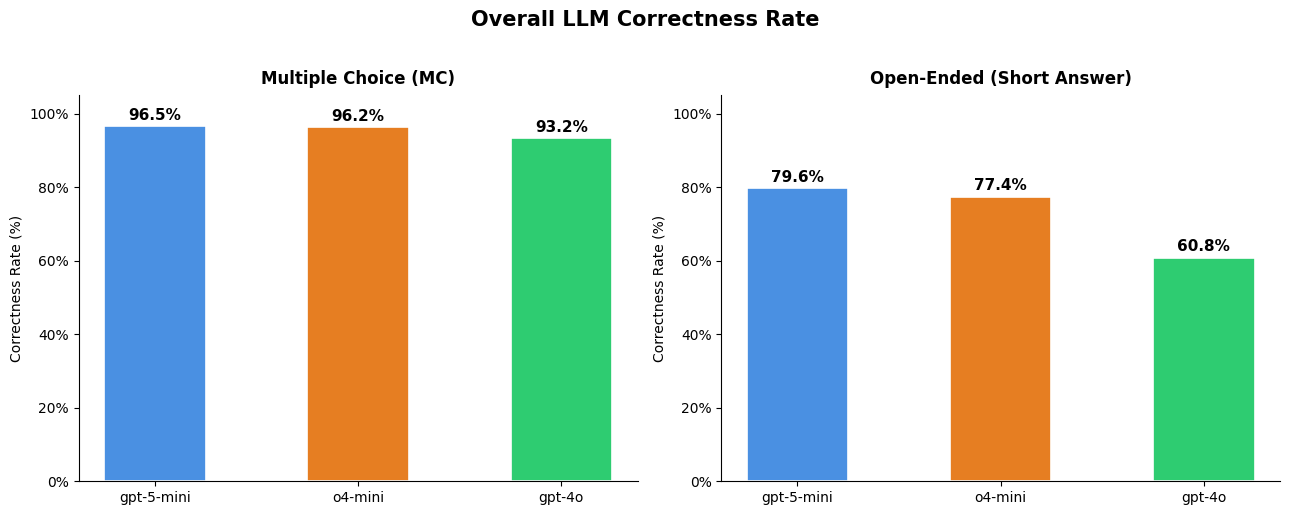

Saved: chart1_overall_correctness.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Overall LLM Correctness Rate', fontsize=15, fontweight='bold', y=1.02)

for ax, mode, label in zip(axes, ['mc', 'oe'], ['Multiple Choice (MC)', 'Open-Ended (Short Answer)']):
    rates = {llm: df[f'{mode}_{llm}'].mean() * 100 for llm in LLMs}
    bars = ax.bar(list(rates.keys()), list(rates.values()),
                  color=[COLORS[l] for l in LLMs], width=0.5, edgecolor='white', linewidth=1.2)
    ax.set_title(label, fontsize=12, fontweight='bold', pad=8)
    ax.set_ylim(0, 105)
    ax.set_ylabel('Correctness Rate (%)', fontsize=10)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='x', labelsize=10)
    for bar, (llm, rate) in zip(bars, rates.items()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{rate:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('chart1_overall_correctness.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart1_overall_correctness.png")


## 2. LLM Correctness Rate by CTF Challenge Type (Multiple Choice)

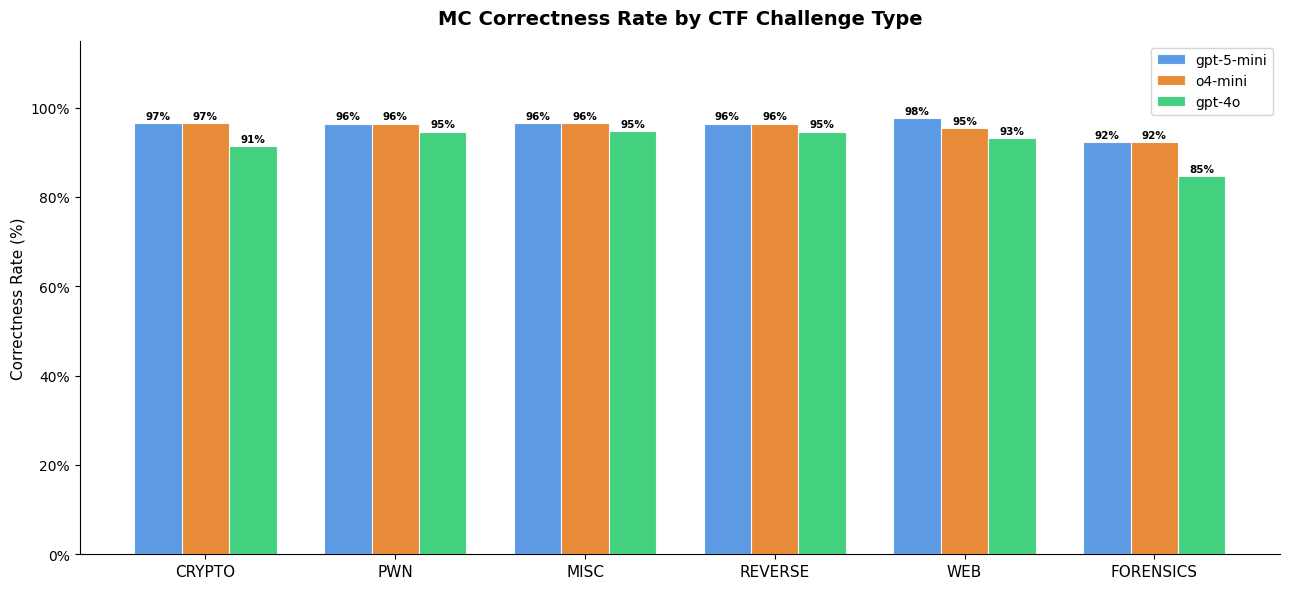

In [4]:
mc_by_type = pd.DataFrame({
    llm: df.groupby('type')[f'mc_{llm}'].mean() * 100
    for llm in LLMs
}).reindex(TYPES).fillna(0)

x = np.arange(len(TYPES))
w = 0.25
fig, ax = plt.subplots(figsize=(13, 6))
for i, (llm, color) in enumerate(COLORS.items()):
    bars = ax.bar(x + (i - 1) * w, mc_by_type[llm], w, label=llm, color=color,
                  alpha=0.9, edgecolor='white', linewidth=0.8)
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{h:.0f}%',
                    ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_title('MC Correctness Rate by CTF Challenge Type', fontsize=14, fontweight='bold', pad=12)
ax.set_xticks(x)
ax.set_xticklabels([t.upper() for t in TYPES], fontsize=11)
ax.set_ylabel('Correctness Rate (%)', fontsize=11)
ax.set_ylim(0, 115)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=10, framealpha=0.8)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart2_mc_by_type.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. LLM Correctness Rate by CTF Challenge Type (Open-Ended)

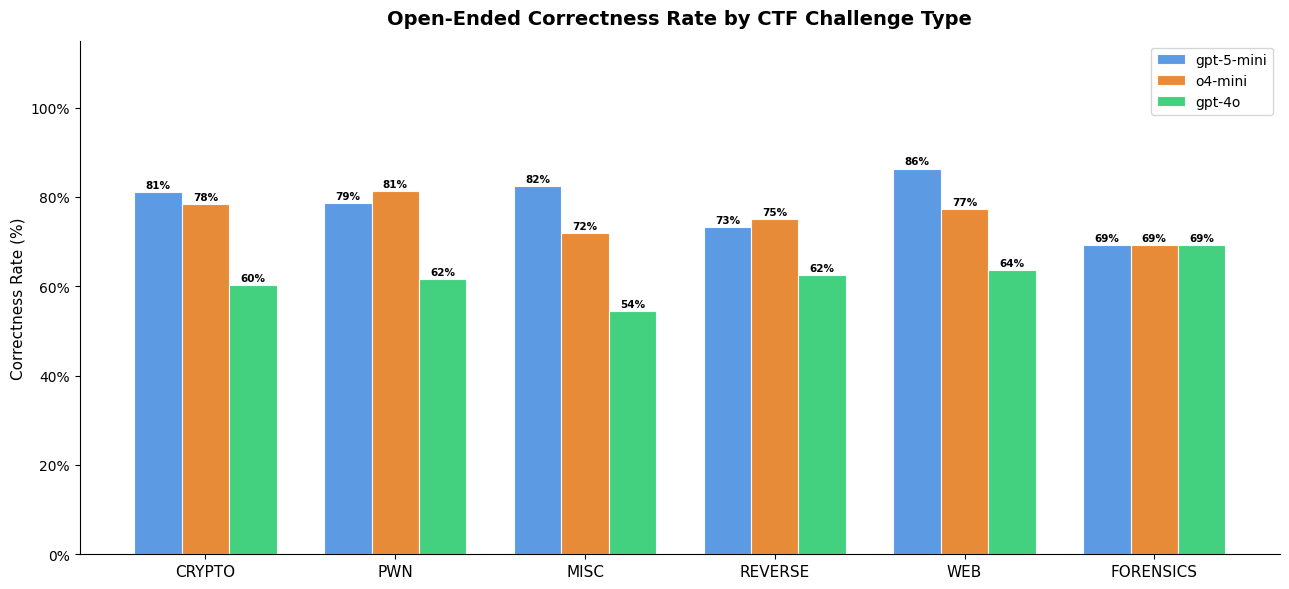

In [5]:
oe_by_type = pd.DataFrame({
    llm: df.groupby('type')[f'oe_{llm}'].mean() * 100
    for llm in LLMs
}).reindex(TYPES).fillna(0)

x = np.arange(len(TYPES))
w = 0.25
fig, ax = plt.subplots(figsize=(13, 6))
for i, (llm, color) in enumerate(COLORS.items()):
    bars = ax.bar(x + (i - 1) * w, oe_by_type[llm], w, label=llm, color=color,
                  alpha=0.9, edgecolor='white', linewidth=0.8)
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{h:.0f}%',
                    ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_title('Open-Ended Correctness Rate by CTF Challenge Type', fontsize=14, fontweight='bold', pad=12)
ax.set_xticks(x)
ax.set_xticklabels([t.upper() for t in TYPES], fontsize=11)
ax.set_ylabel('Correctness Rate (%)', fontsize=11)
ax.set_ylim(0, 115)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=10, framealpha=0.8)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart3_oe_by_type.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Total Score by LLM Model (MC Scoring)

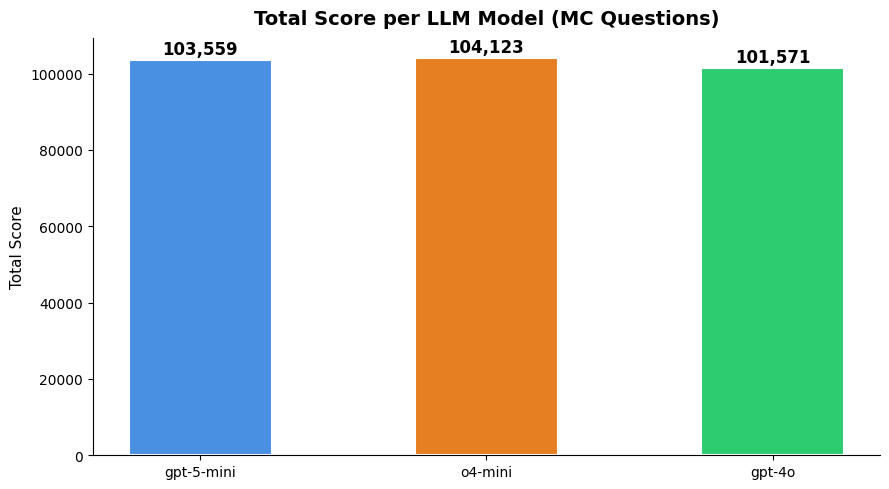

In [6]:
valid_score = df[df['score'] > 0].copy()

score_by_llm = {}
for llm in LLMs:
    score_by_llm[llm] = (valid_score[f'mc_{llm}'] * valid_score['score']).sum()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(list(score_by_llm.keys()), list(score_by_llm.values()),
              color=[COLORS[l] for l in LLMs], width=0.5, edgecolor='white', linewidth=1.5)
ax.set_title('Total Score per LLM Model (MC Questions)', fontsize=14, fontweight='bold', pad=10)
ax.set_ylabel('Total Score', fontsize=11)
ax.spines[['top','right']].set_visible(False)
for bar, score in zip(bars, score_by_llm.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{score:,.0f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_total_score.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Total Score by CTF Type per LLM (Stacked)

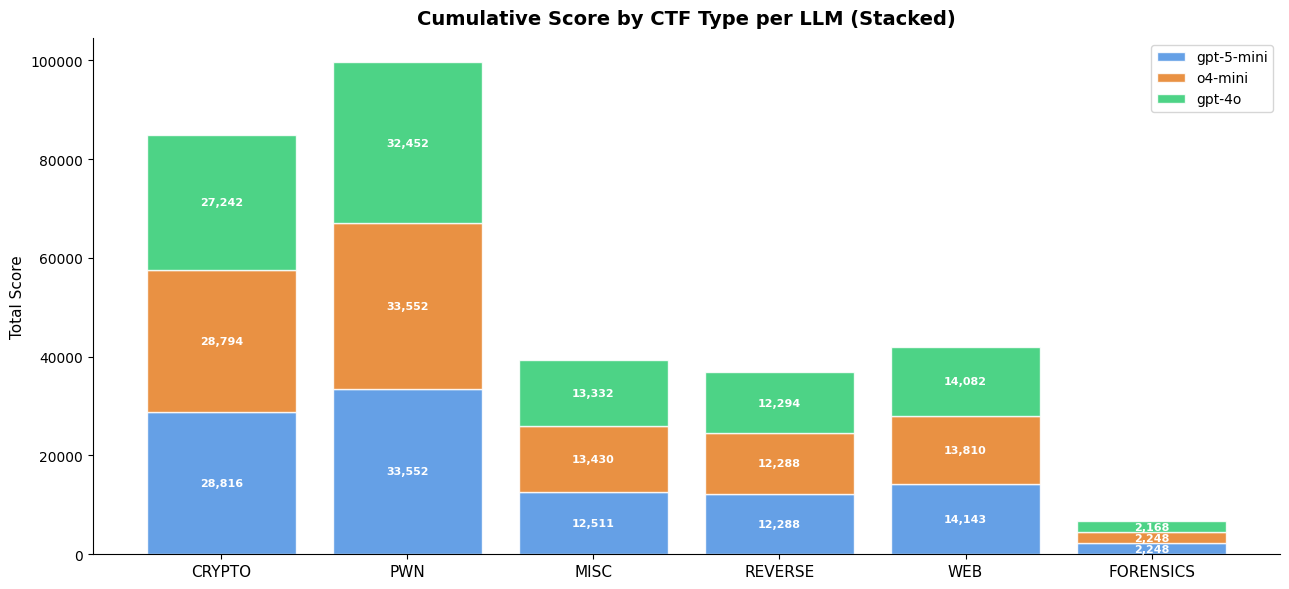

In [7]:
score_type = {}
for llm in LLMs:
    score_type[llm] = valid_score.groupby('type').apply(
        lambda g: (g[f'mc_{llm}'] * g['score']).sum()
    ).reindex(TYPES).fillna(0)

score_type_df = pd.DataFrame(score_type).reindex(TYPES)

fig, ax = plt.subplots(figsize=(13, 6))
bottom = np.zeros(len(TYPES))
x = np.arange(len(TYPES))
for i, (llm, color) in enumerate(COLORS.items()):
    vals = score_type_df[llm].values
    bars = ax.bar(x, vals, bottom=bottom, label=llm, color=color, alpha=0.85, edgecolor='white')
    for j, (bar, v) in enumerate(zip(bars, vals)):
        if v > 1000:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bottom[j] + v/2, f'{v:,.0f}',
                    ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    bottom += vals

ax.set_title('Cumulative Score by CTF Type per LLM (Stacked)', fontsize=14, fontweight='bold', pad=10)
ax.set_xticks(x)
ax.set_xticklabels([t.upper() for t in TYPES], fontsize=11)
ax.set_ylabel('Total Score', fontsize=11)
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart5_score_by_type_stacked.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Open-Ended Correctness Rate by Difficulty Level

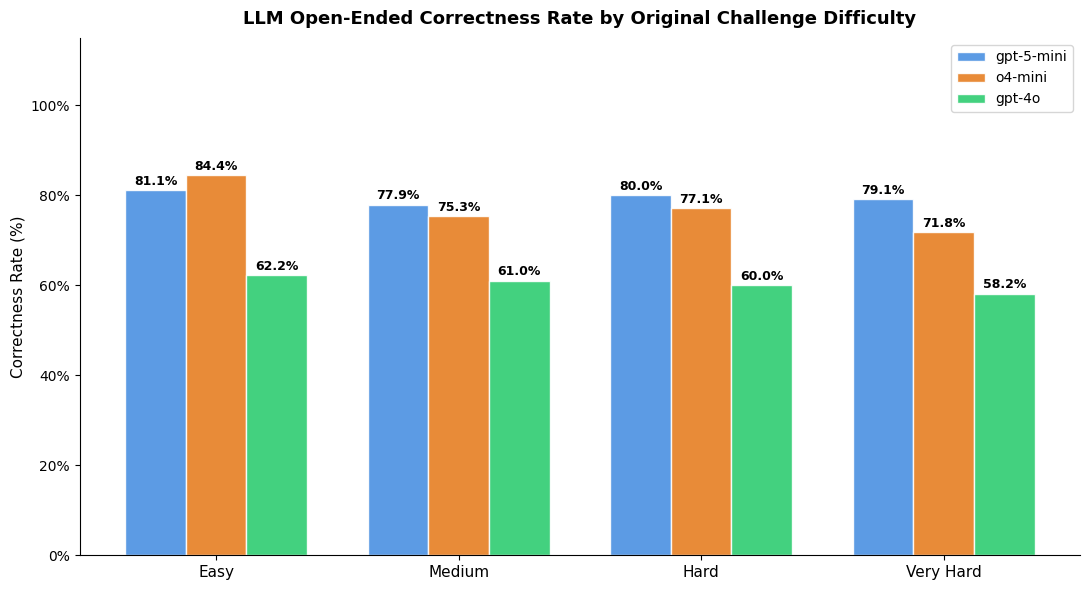

In [8]:
diff_order = ['Easy', 'Medium', 'Hard', 'Very Hard']
df_diff = df[df['diff_bin'] != 'N/A'].copy()
oe_by_diff = pd.DataFrame({
    llm: df_diff.groupby('diff_bin')[f'oe_{llm}'].mean() * 100
    for llm in LLMs
}).reindex(diff_order).fillna(0)

x = np.arange(len(diff_order))
w = 0.25
fig, ax = plt.subplots(figsize=(11, 6))
for i, (llm, color) in enumerate(COLORS.items()):
    bars = ax.bar(x + (i-1)*w, oe_by_diff[llm], w, label=llm, color=color,
                  alpha=0.9, edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{h:.1f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title("LLM Open-Ended Correctness Rate by Original Challenge Difficulty", fontsize=13, fontweight='bold', pad=10)
ax.set_xticks(x)
ax.set_xticklabels(diff_order, fontsize=11)
ax.set_ylabel('Correctness Rate (%)', fontsize=11)
ax.set_ylim(0, 115)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart6_oe_by_difficulty.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Multiple Choice Correctness Rate by Difficulty Level

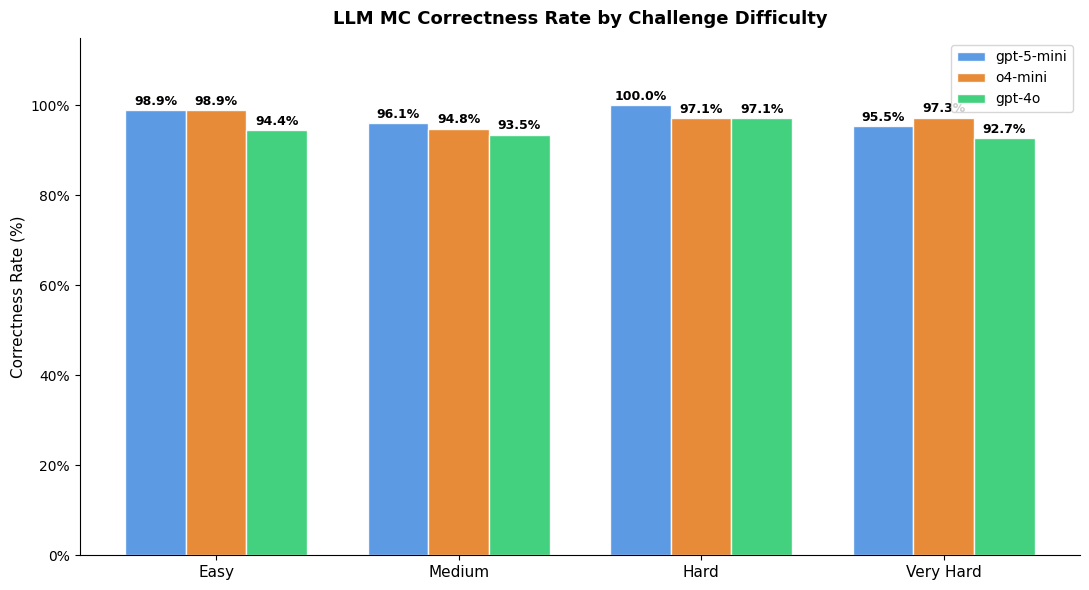

In [9]:
mc_by_diff = pd.DataFrame({
    llm: df_diff.groupby('diff_bin')[f'mc_{llm}'].mean() * 100
    for llm in LLMs
}).reindex(diff_order).fillna(0)

x = np.arange(len(diff_order))
w = 0.25
fig, ax = plt.subplots(figsize=(11, 6))
for i, (llm, color) in enumerate(COLORS.items()):
    bars = ax.bar(x + (i-1)*w, mc_by_diff[llm], w, label=llm, color=color,
                  alpha=0.9, edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{h:.1f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title("LLM MC Correctness Rate by Challenge Difficulty", fontsize=13, fontweight='bold', pad=10)
ax.set_xticks(x)
ax.set_xticklabels(diff_order, fontsize=11)
ax.set_ylabel('Correctness Rate (%)', fontsize=11)
ax.set_ylim(0, 115)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart7_mc_by_difficulty.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. WEB Challenge: MC vs Open-Ended Correctness per LLM

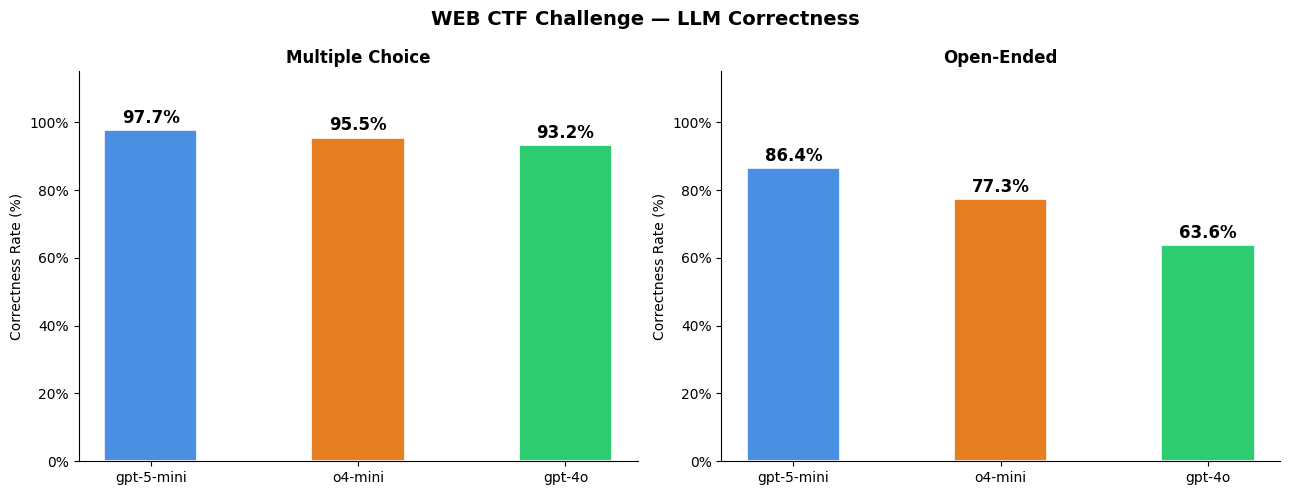

Web questions count: 44


In [10]:
web_df = df[df['type'] == 'web'].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('WEB CTF Challenge — LLM Correctness', fontsize=14, fontweight='bold')

for ax, mode, label in zip(axes, ['mc', 'oe'], ['Multiple Choice', 'Open-Ended']):
    rates = {llm: web_df[f'{mode}_{llm}'].mean() * 100 for llm in LLMs}
    bars = ax.bar(list(rates.keys()), list(rates.values()),
                  color=[COLORS[l] for l in LLMs], width=0.45, edgecolor='white', linewidth=1.2)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 115)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.spines[['top','right']].set_visible(False)
    for bar, (llm, rate) in zip(bars, rates.items()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{rate:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax.set_ylabel('Correctness Rate (%)')

plt.tight_layout()
plt.savefig('chart8_web_correctness.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Web questions count: {len(web_df)}")


## 9. Heatmap: Correctness Rate by LLM × CTF Type

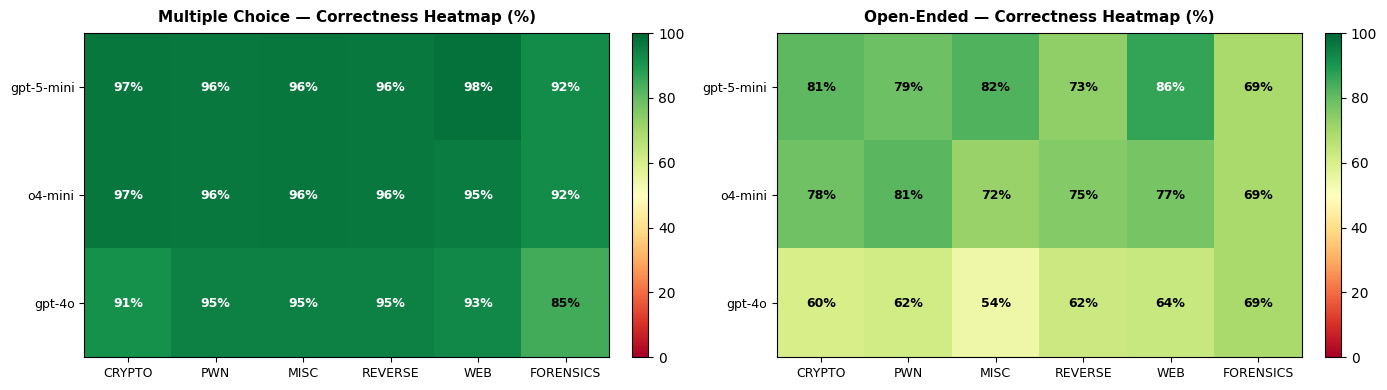

In [11]:
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, mode, label in zip(axes, ['mc', 'oe'], ['Multiple Choice', 'Open-Ended']):
    heat_data = pd.DataFrame({
        llm: df.groupby('type')[f'{mode}_{llm}'].mean() * 100
        for llm in LLMs
    }).reindex(TYPES)

    im = ax.imshow(heat_data.values.T, aspect='auto', cmap='RdYlGn', vmin=0, vmax=100)
    ax.set_title(f'{label} — Correctness Heatmap (%)', fontsize=11, fontweight='bold', pad=8)
    ax.set_xticks(range(len(TYPES)))
    ax.set_xticklabels([t.upper() for t in TYPES], fontsize=9)
    ax.set_yticks(range(len(LLMs)))
    ax.set_yticklabels(LLMs, fontsize=9)
    for i in range(len(LLMs)):
        for j in range(len(TYPES)):
            val = heat_data.values[j, i]
            ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                    fontsize=9, fontweight='bold',
                    color='black' if 30 < val < 85 else 'white')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('chart9_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Dataset Distribution: Questions by Type and Difficulty

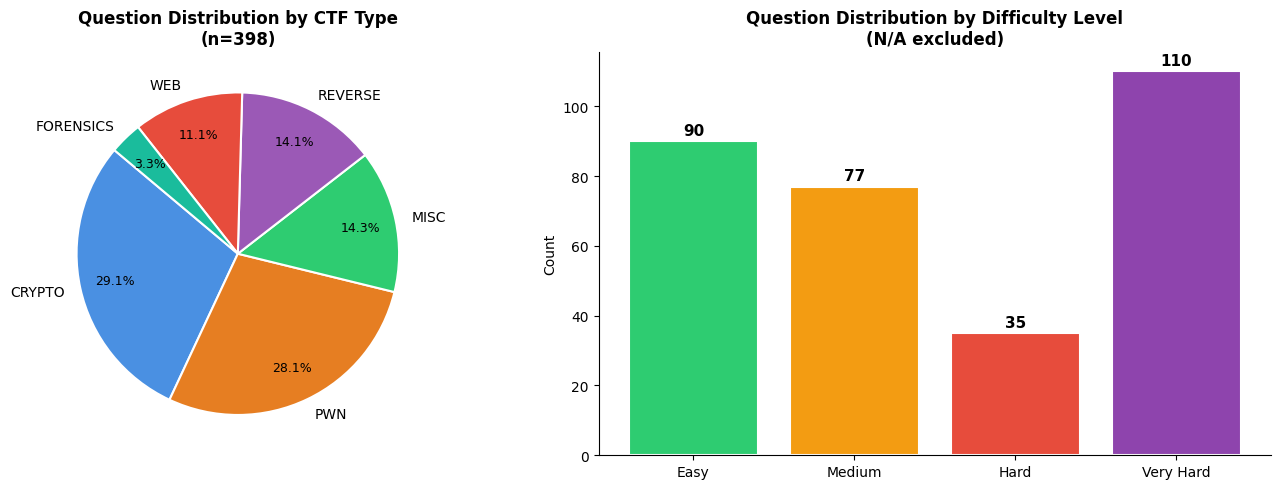

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Type distribution
type_counts = df['type'].value_counts().reindex(TYPES)
wedges, texts, autotexts = axes[0].pie(
    type_counts.values, labels=[t.upper() for t in type_counts.index],
    colors=TYPE_COLORS, autopct='%1.1f%%', startangle=140,
    pctdistance=0.78, wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for t in autotexts: t.set_fontsize(9)
axes[0].set_title('Question Distribution by CTF Type\n(n=398)', fontsize=12, fontweight='bold')

# Difficulty distribution (exclude N/A)
diff_counts = df[df['diff_bin'] != 'N/A']['diff_bin'].value_counts().reindex(diff_order)
diff_colors = ['#2ECC71','#F39C12','#E74C3C','#8E44AD']
bars = axes[1].bar(diff_counts.index, diff_counts.values, color=diff_colors,
                   edgecolor='white', linewidth=1.5)
axes[1].set_title('Question Distribution by Difficulty Level\n(N/A excluded)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].spines[['top','right']].set_visible(False)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(int(bar.get_height())), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('chart10_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. MC vs Open-Ended Gap (Δ) by Type per LLM
*Positive = MC scored higher; Negative = OE scored higher*

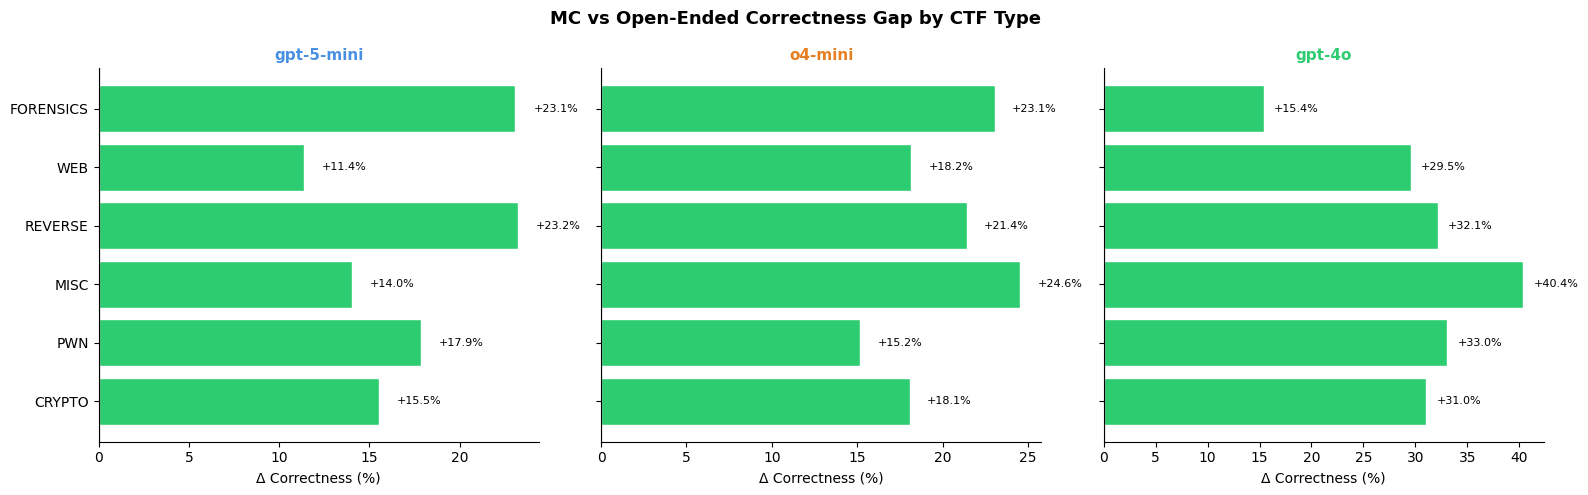

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle('MC vs Open-Ended Correctness Gap by CTF Type', fontsize=13, fontweight='bold')

for ax, llm in zip(axes, LLMs):
    mc_r = df.groupby('type')[f'mc_{llm}'].mean() * 100
    oe_r = df.groupby('type')[f'oe_{llm}'].mean() * 100
    delta = (mc_r - oe_r).reindex(TYPES)
    colors = ['#2ECC71' if v >= 0 else '#E74C3C' for v in delta]
    bars = ax.barh(range(len(TYPES)), delta.values, color=colors, edgecolor='white')
    ax.set_yticks(range(len(TYPES)))
    ax.set_yticklabels([t.upper() for t in TYPES], fontsize=10)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(llm, fontsize=11, fontweight='bold', color=COLORS[llm])
    ax.set_xlabel('Δ Correctness (%)')
    ax.spines[['top','right']].set_visible(False)
    for bar, v in zip(bars, delta.values):
        ax.text(v + (1 if v >= 0 else -1), bar.get_y() + bar.get_height()/2,
                f'{v:+.1f}%', va='center', ha='left' if v >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.savefig('chart11_mc_oe_gap.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. Summary Statistics Table

In [ ]:
summary_rows = []
for llm in LLMs:
    mc_rate = df[f'mc_{llm}'].mean() * 100
    oe_rate = df[f'oe_{llm}'].mean() * 100
    total_score = (df[df['score'] > 0][f'mc_{llm}'] * df[df['score'] > 0]['score']).sum()
    best_type_mc = df.groupby('type')[f'mc_{llm}'].mean().idxmax()
    worst_type_mc = df.groupby('type')[f'mc_{llm}'].mean().idxmin()
    summary_rows.append({
        'Model': llm,
        'MC Correct Rate': f'{mc_rate:.1f}%',
        'OE Correct Rate': f'{oe_rate:.1f}%',
        'Total MC Score': f'{total_score:,.0f}',
        'Best Type (MC)': best_type_mc.upper(),
        'Worst Type (MC)': worst_type_mc.upper(),
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
summary_df.to_csv('ctf_llm_summary.csv', index=False)
print("\nSaved: ctf_llm_summary.csv")
